In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# EDA -> exploratory data analysis

#1. ANALYSIS
  * UNIVARIATE ANALYSIS
  * MULTIVARIATE ANALYSIS
# 2. FEATURE ENGINEERING
  * CREATING NEW COLOUMNS
  * MODIFYING EXISTING ONE
#3. HANDLING OUTLIERS
  * DETECT OUTLIERS
  * REMOVE OUTLIERS

**The process of data analysis is highly iterative **

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

In [ ]:
# shape
df.shape

(891, 12)

In [ ]:
# previewing the data
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# listing the coloumns
df.columns.values

array(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

dividing the data into categories
1. CATEGORIAL COLUMNS
  * survived , Pclass , sex , SibSp , Parch ,  embarked  
2. NUMERICAL COLUMNS
  * PassengerId , Age , Fare
3. MIXED COLUMNS
  * Name , Ticket , Cabin

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
# getting the missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


1. missing values are in age , cabin and embarked columns
2. most of the missing values are in the cabin coloumn , so it needs to be droppped
3. few columns have inappropriate data type

In [ ]:
df.drop( columns = ["Cabin"] , inplace = True )

In [ ]:
# inputting missing data for the age coloumn
# strategy = mean
df["Age"].fillna(df["Age"].mean() , inplace = True)

In [ ]:
# inputting missing data for the Embarked coloumn
# strategy --> maximum appeared value
df["Embarked"].value_counts()

# S -> has the most values
df["Embarked"].fillna('S' , inplace = True)

/tmp/ipykernel_3416/1367019035.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna('S' , inplace = True)


In [ ]:
# now checking for the missing values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# want to check more -> SibSp , ParCh\
df["SibSp"].value_counts()

,count
SibSp,
0,608
1,209
2,28
4,18
3,16
8,7
5,5


In [ ]:
df["Parch"].value_counts()

,count
Parch,
0,678
1,118
2,80
5,5
3,5
4,4
6,1


changing data types of some classes

In [ ]:
# survived      (int -> category)
# age           (float -> int)
# Pclass        (int -> category)
# sex           (int -> category)
# embarked      (mixed -> category)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    object  
dtypes: category(1), float64(2), int64(4), object(4)
memory usage: 70.7+ KB


In [ ]:
df['Survived']      =    df['Survived'].astype('category')
df['Age']           =    df['Age'].astype('int')
df['Pclass']        =    df['Pclass'].astype('category')
df['Sex']           =    df['Sex'].astype('category')
df['Embarked']      =    df['Embarked'].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    object  
dtypes: category(1), float64(2), int64(4), object(4)
memory usage: 70.7+ KB


In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.0500,S


In [ ]:
# get summary
df.describe()

,PassengerId,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,29.544332,0.523008,0.381594,32.204208
std,257.353842,13.013778,1.102743,0.806057,49.693429
min,1.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,29.000000,0.000000,0.000000,14.454200
75%,668.500000,35.000000,1.000000,0.000000,31.000000
max,891.000000,80.000000,8.000000,6.000000,512.329200


UNIVARIATE ANALYSIS

Out of 891 62% people dies in the accident 
Out of 891 38% people survived in the accident 


/tmp/ipykernel_3416/3994626221.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot( x = df['Survived'] , palette = "Set1")


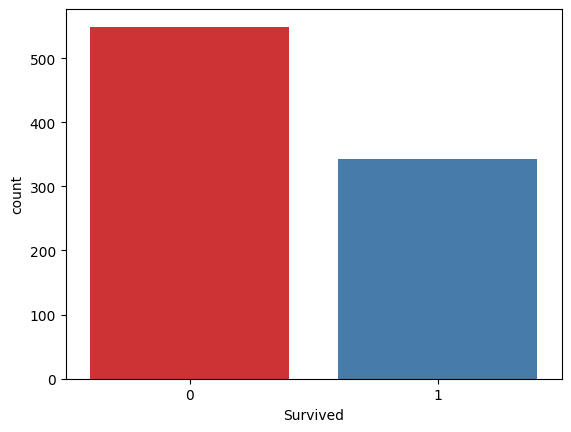

In [ ]:
# let's start with the Survived coloumn
sns.countplot( x = df['Survived'] , palette = "Set1")
death_percent = round( ( df['Survived'].value_counts().values[0]/891 ) * 100 )
surv_percent = round( ( df['Survived'].value_counts().values[1]/891 ) * 100 )
print("Out of 891 {}% people dies in the accident ".format(death_percent))
print("Out of 891 {}% people survived in the accident ".format(surv_percent))

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


<Axes: xlabel='Pclass', ylabel='count'>

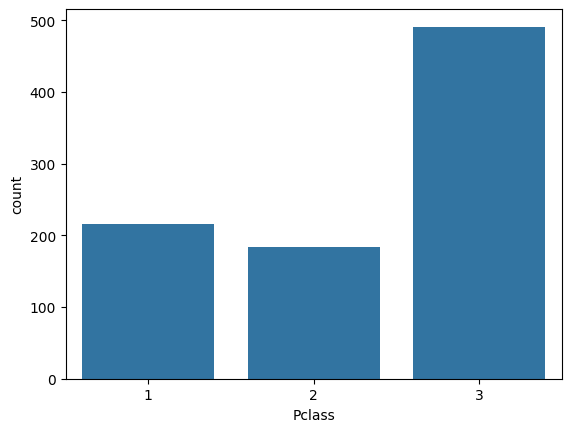

In [ ]:
# pclass coloumn
print( df["Pclass"].value_counts() )
sns.countplot( x = df['Pclass'] )

Sex
male      577
female    314
Name: count, dtype: int64
Sex
male      64.758698
female    35.241302
Name: count, dtype: float64


/tmp/ipykernel_3416/824092672.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot( x = df['Sex'] , palette ="Set2")


<Axes: xlabel='Sex', ylabel='count'>

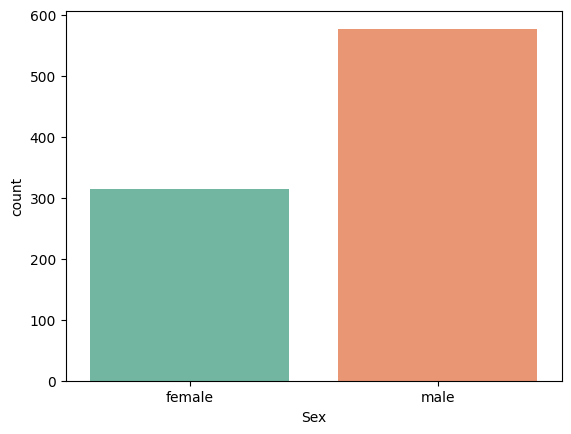

In [ ]:
# to get the values of sex coloumn
print( df["Sex"].value_counts() )

# for percentage ratio
print(df["Sex"].value_counts()/891 * 100)
sns.countplot( x = df['Sex'] , palette ="Set2")

SibSp
0    68.237935
1    23.456790
2     3.142536
4     2.020202
3     1.795735
8     0.785634
5     0.561167
Name: count, dtype: float64


/tmp/ipykernel_3416/1145430104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot( x = df['SibSp'] , palette ="Set1")


<Axes: xlabel='SibSp', ylabel='count'>

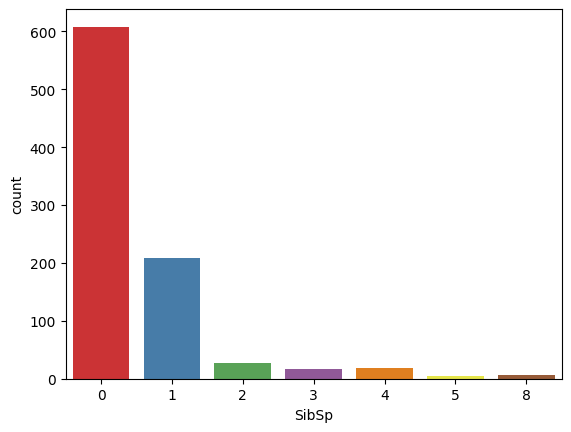

In [ ]:
# percentage of SibSp
print( df["SibSp"].value_counts()/891 * 100 )
sns.countplot( x = df['SibSp'] , palette ="Set1")

Parch
0    76.094276
1    13.243547
2     8.978676
5     0.561167
3     0.561167
4     0.448934
6     0.112233
Name: count, dtype: float64


<Axes: xlabel='Parch', ylabel='count'>

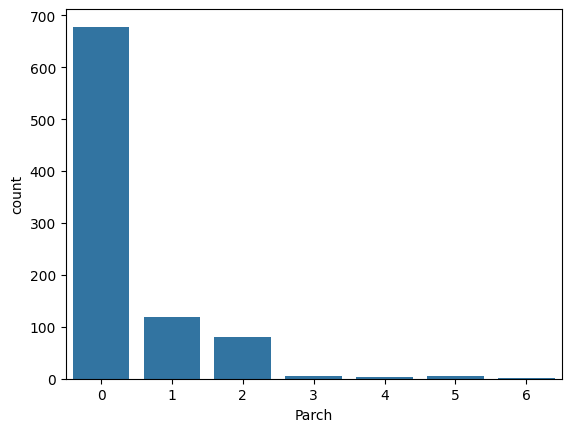

In [ ]:
# parch percentages
print( df["Parch"].value_counts()/891 * 100 )
sns.countplot( x = df["Parch"] )

Embarked
S    72.502806
C    18.855219
Q     8.641975
Name: count, dtype: float64


<Axes: xlabel='Embarked', ylabel='count'>

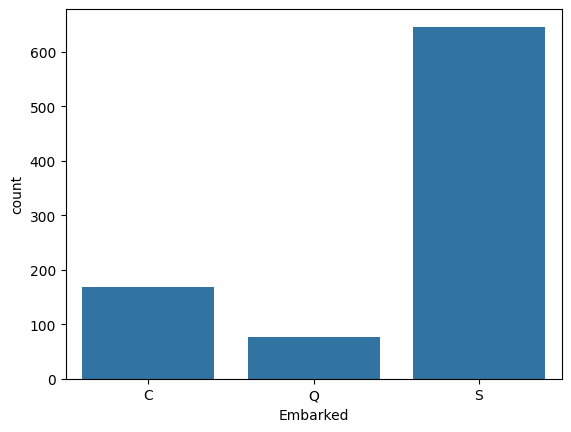

In [ ]:
# embarked percentages
print( df["Embarked"].value_counts()/891 * 100 )
sns.countplot( x = df["Embarked"] )

# DISTPLOT
A distplot (distribution plot) is used to understand how the values of a numerical column are distributed.

It answers questions like:

Where are most values concentrated?
Is the data symmetric or skewed?
Are there outliers?
Does the data look normally distributed?

sns.distplot()

/tmp/ipykernel_3416/1938458142.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( df["Age"] )


skewness :  0.45956263424701577
kurtosis :  0.9865867453652877


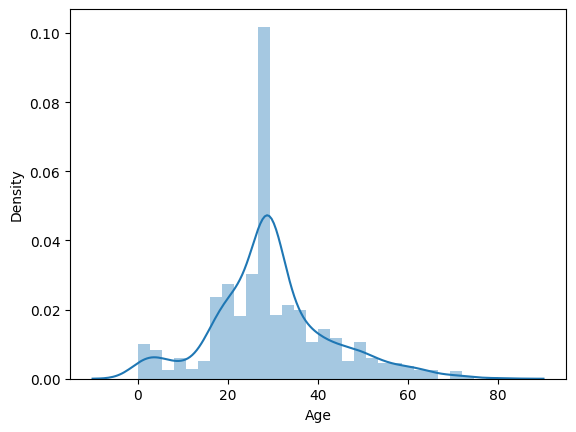

In [ ]:
# AGE - COLUMN
sns.distplot( df["Age"] )
print( "skewness : " , df["Age"].skew() )
print( "kurtosis : " , df["Age"].kurt() )

<Axes: xlabel='Age'>

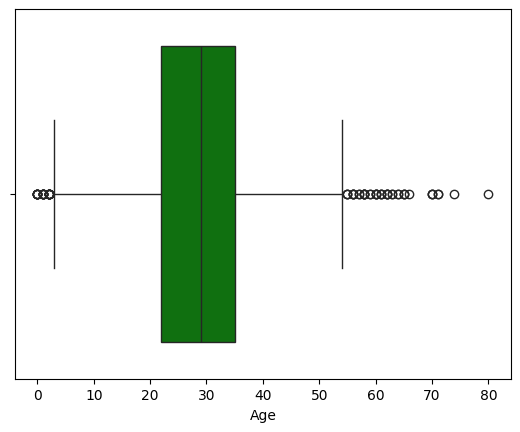

In [ ]:
# BOXPLOT OF AGE
sns.boxplot( x = df["Age"] , color = "green" )

In [ ]:
# people between the age of 60 and 70 are
print( "people between the age of 60 and 70 are : ", df[(df["Age"] > 60) & (df["Age"] < 70)].shape[0] )

# people between the age of 70 and 75 are
print( "people between the age of 70 and 75 are : ", df[(df["Age"] > 70) & (df["Age"] < 75)].shape[0] )

# people greater then the age of 75  are
print( "people greater then the age of 75  are : ", df[(df["Age"] > 75)].shape[0] )

print('-'*50)

print("people between the age of 0 and 1 are : ",df[ (df["Age"] < 1) ].shape[0] )

people between the age of 60 and 70 are :  15
people between the age of 70 and 75 are :  3
people greater then the age of 75  are :  1
--------------------------------------------------
people between the age of 0 and 1 are :  7


for all purposes age can be considered in a normal distribution

deeper analysis is required for outlier detection

/tmp/ipykernel_3416/1872845552.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( x = df["Fare"] )


skewness :  4.787316519674893
kurtosis :  33.39814088089868


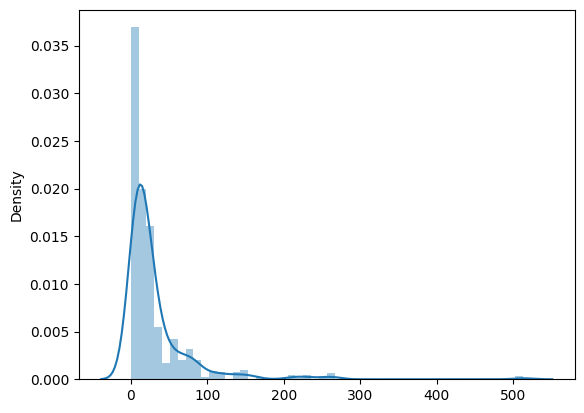

In [ ]:
# FARE - COLUMN
sns.distplot( x = df["Fare"] )
print( "skewness : " , df["Fare"].skew() )
print( "kurtosis : " , df["Fare"].kurt() )

<Axes: xlabel='Fare'>

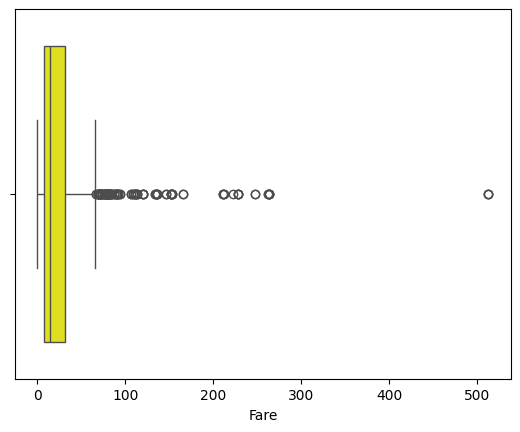

In [ ]:
# BOXPLOT
sns.boxplot(x = df["Fare"] , color = "yellow")

In [ ]:
print("people with fair in between 200$ and 300$ are : ",df[ (df["Fare"] > 200)  & (df["Fare"] < 300) ].shape[0] )
print("people with fair greater then 300$ are : ",df[ (df["Fare"] > 300) ].shape[0] )

people with fair in between 200$ and 300$ are :  17
people with fair greater then 300$ are :  3


highlt skewed data , a lot people buy cheaper tickets
outliers are their on the data

# MULTIVARIATE - ANALYSIS

Survived,0,1
Pclass,,
1,37.0,63.0
2,52.7,47.3
3,75.8,24.2


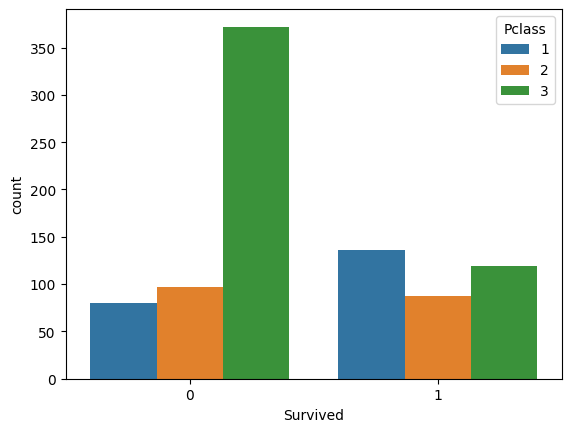

In [ ]:
# survival with Pclass
sns.countplot( x =df["Survived"] , hue = df["Pclass"] )

pd.crosstab( df['Pclass'] , df['Survived']).apply(
    lambda r: round(r / r.sum() * 100, 1),
    axis=1
)

Survived,0,1
Embarked,,
C,44.6,55.4
Q,61.0,39.0
S,66.1,33.9


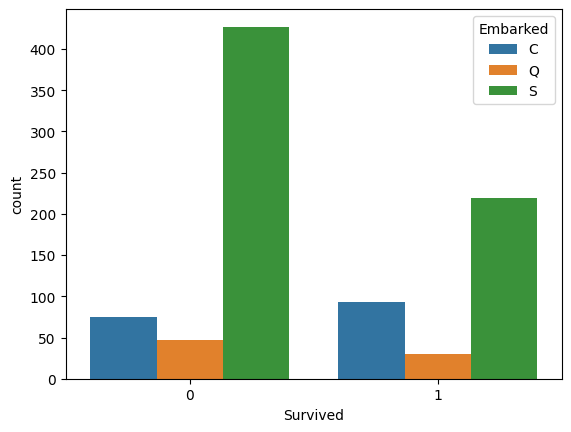

In [ ]:
# SURVIVAL WITH EMBARKED
sns.countplot( x =df["Survived"] , hue = df["Embarked"] )

pd.crosstab( df['Embarked'] , df['Survived']).apply(
    lambda r: round(r / r.sum() * 100, 1),
    axis=1
)

/tmp/ipykernel_3416/2873844251.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( df[df["Survived"] == 0]['Age'] )
/tmp/ipykernel_3416/2873844251.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( df[df["Survived"] == 1]['Age'] )


<Axes: xlabel='Age', ylabel='Density'>

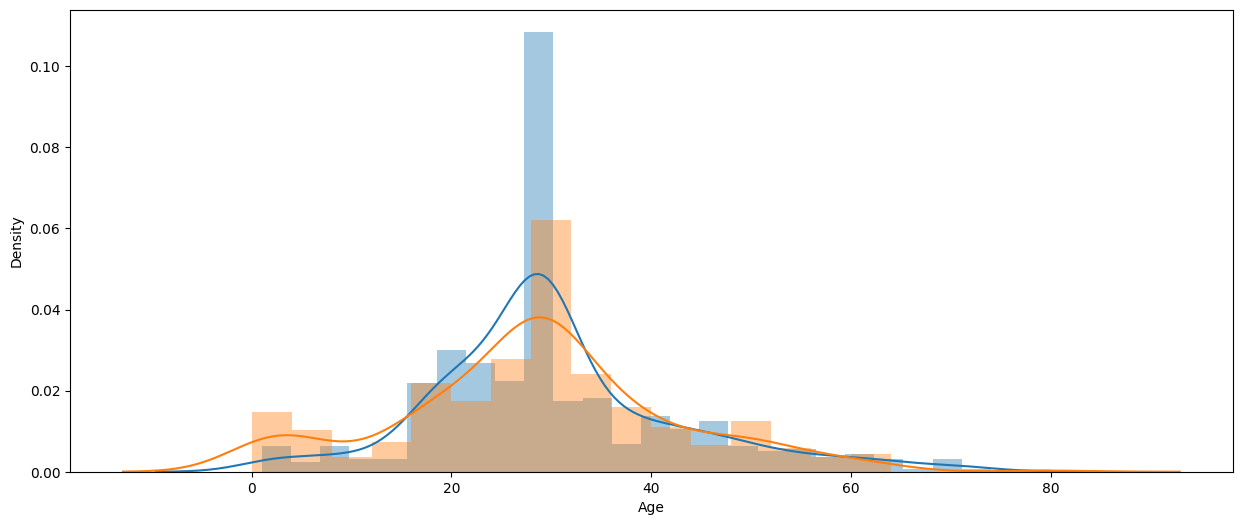

In [ ]:
# SURVIVAL WITH AGE
plt.figure( figsize = (15,6) )
sns.distplot( df[df["Survived"] == 0]['Age'] )
sns.distplot( df[df["Survived"] == 1]['Age'] )

/tmp/ipykernel_3416/2545663582.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( df[df["Survived"] == 0]['Fare'] )
/tmp/ipykernel_3416/2545663582.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( df[df["Survived"] == 1]['Fare'] )


<Axes: xlabel='Fare', ylabel='Density'>

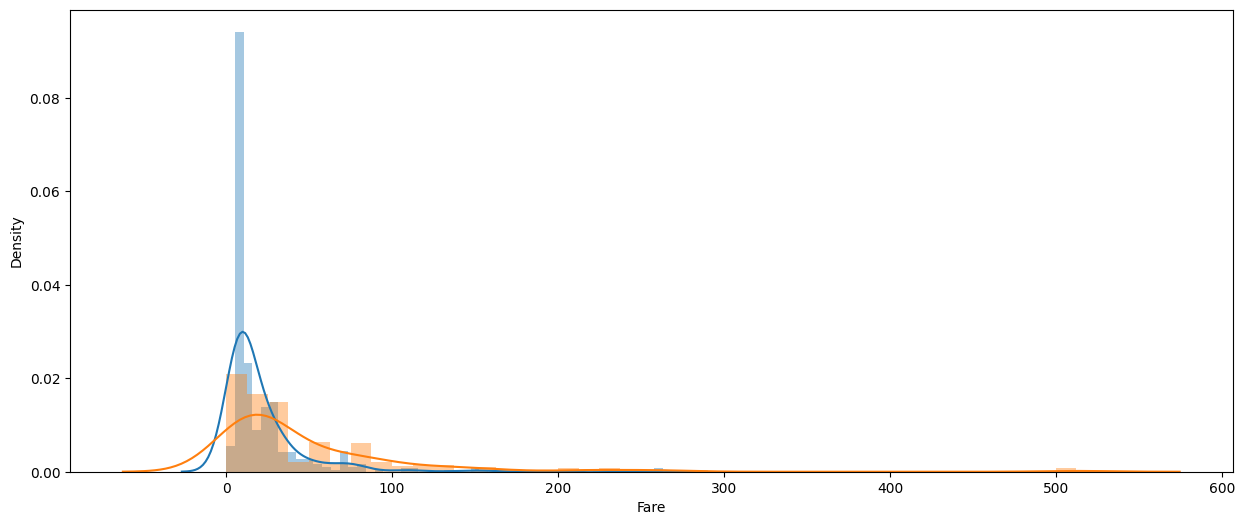

In [ ]:
# SURVIVAL WITH FARE
plt.figure( figsize = (15,6) )
sns.distplot( df[df["Survived"] == 0]['Fare'] )
sns.distplot( df[df["Survived"] == 1]['Fare'] )

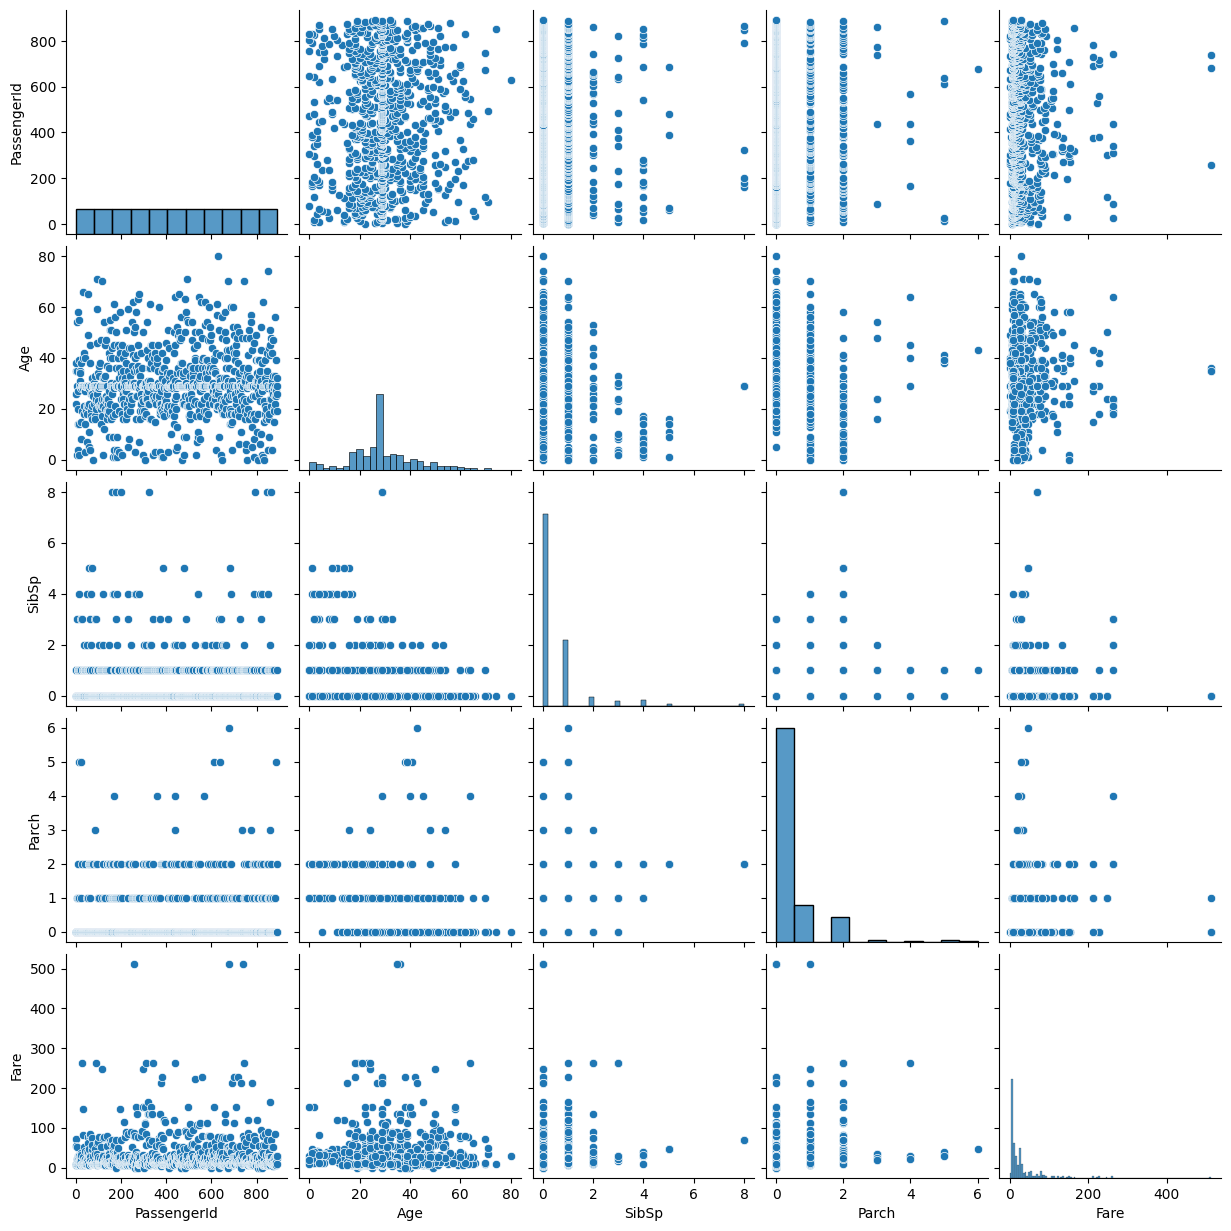

In [ ]:
sns.pairplot(df)

PassengerId       int64
Survived       category
Pclass         category
Name             object
Sex            category
Age               int64
SibSp             int64
Parch             int64
Ticket           object
Fare            float64
Embarked       category
dtype: object


<Axes: >

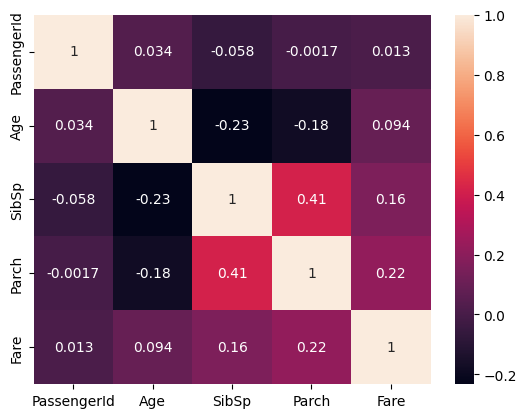

In [ ]:
# HEATMAP
print(df.dtypes)
columns = ["PassengerId" , "Age" , "SibSp" , "Parch" , "Fare"]
sns.heatmap(df[columns].corr() , annot = True )

FEATURE ENGINEERING

In [ ]:
# WE WILL MAKE A NEW COLOUMN BY COMBINING THE SIBSP COLOUMN AND PARCH COLOUMN TO A NEW COLUMN NAMED -> FAMILY SIZE
df['family_size'] = df['SibSp'] + df['Parch']

In [ ]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size
451,452,0,3,"Hagland, Mr. Ingvald Olai Olsen",male,29,1,0,65303,19.9667,S,1
693,694,0,3,"Saad, Mr. Khalil",male,25,0,0,2672,7.2250,C,0
364,365,0,3,"O'Brien, Mr. Thomas",male,29,1,0,370365,15.5000,Q,1
63,64,0,3,"Skoog, Master. Harald",male,4,3,2,347088,27.9000,S,5
395,396,0,3,"Johansson, Mr. Erik",male,22,0,0,350052,7.7958,S,0


In [ ]:
# NOW WE WILL ENGINEER A NEW FEATURE WITH THE NAME OF FAMILY TYPE
def family_type(number):
  if(number == 0):
    return 'Alone'
  elif (number <= 4):
    return 'Medium'
  else:
    return 'Large'

In [ ]:
df['Family_type'] = df['family_size'].apply(family_type)

In [ ]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,family_size,Family_type
617,618,0,3,"Lobb, Mrs. William Arthur (Cordelia K Stanlick)",female,26,1,0,A/5. 3336,16.1000,S,1,Medium
219,220,0,2,"Harris, Mr. Walter",male,30,0,0,W/C 14208,10.5000,S,0,Alone
351,352,0,1,"Williams-Lambert, Mr. Fletcher Fellows",male,29,0,0,113510,35.0000,S,0,Alone
342,343,0,2,"Collander, Mr. Erik Gustaf",male,28,0,0,248740,13.0000,S,0,Alone
496,497,1,1,"Eustis, Miss. Elizabeth Mussey",female,54,1,0,36947,78.2667,C,1,Medium


In [ ]:
# dropping SibSp , Parch , family_size
df.drop( columns = ["SibSp" , "Parch" , "family_size"] , inplace = True)

In [ ]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,Family_type
655,656,0,2,"Hickman, Mr. Leonard Mark",male,24,S.O.C. 14879,73.5000,S,Medium
342,343,0,2,"Collander, Mr. Erik Gustaf",male,28,248740,13.0000,S,Alone
349,350,0,3,"Dimic, Mr. Jovan",male,42,315088,8.6625,S,Alone
307,308,1,1,"Penasco y Castellana, Mrs. Victor de Satode (M...",female,17,PC 17758,108.9000,C,Medium
274,275,1,3,"Healy, Miss. Hanora ""Nora""",female,29,370375,7.7500,Q,Alone


In [ ]:
pd.crosstab( df['Family_type'] , df['Survived']).apply(
    lambda r: round(r / r.sum() * 100, 1),
    axis=1
)

Survived,0,1
Family_type,,
Alone,69.6,30.4
Large,85.1,14.9
Medium,44.0,56.0


# DETECTING OUTLIERS

# NUMERICAL DATA
* if the data is following normal distribution , anything beyond 3SD - MEAN + 3SD can be considered as an outlier
* if the data does not follow normal distribution , using boxplot we can eliminate points below Q1 - 1.5 IQR and Q3 + 1.5 IQR

# CATEGORIAL
* if the col is highly imbalanced for eg male 10000 and female 2 then we can eliminate females

In [ ]:
# handling outliers in AGE(almost normal)
df = df [ df["Age"] < ( df['Age'].mean() + 3 * df["Age"].std() ) ]
df.shape

(884, 10)

In [ ]:
# handling outliers in FARE ( not normal distribution)
Q1 = np.percentile(df['Fare'] , 25)
Q3 = np.percentile(df['Fare'] , 75)

outlier_lower = Q1 - 1.5 * (Q3 - Q1)
outlier_upper = Q3 + 1.5 * (Q3 - Q1)

df = df[ (df['Fare'] > outlier_lower) & (df['Fare'] < outlier_upper) ]

In [ ]:
# ONE HOT ENCODING --> means here the categorical columns are converted into numbers
df.sample(4)

# colms to be transformed are Pclass , Sex , Embarked , Family_type
pd.get_dummies( data = df , columns = ["Pclass" , "Sex" , "Embarked" , "Family_type"] , drop_first = True )

,PassengerId,Survived,Name,Age,Ticket,Fare,Pclass_2,Pclass_3,Sex_male,Embarked_Q,Embarked_S,Family_type_Large,Family_type_Medium
0,1,0,"Braund, Mr. Owen Harris",22,A/5 21171,7.2500,False,True,True,False,True,False,True
2,3,1,"Heikkinen, Miss. Laina",26,STON/O2. 3101282,7.9250,False,True,False,False,True,False,False
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35,113803,53.1000,False,False,False,False,True,False,True
4,5,0,"Allen, Mr. William Henry",35,373450,8.0500,False,True,True,False,True,False,False
5,6,0,"Moran, Mr. James",29,330877,8.4583,False,True,True,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,"Montvila, Rev. Juozas",27,211536,13.0000,True,False,True,False,True,False,False
887,888,1,"Graham, Miss. Margaret Edith",19,112053,30.0000,False,False,False,False,True,False,False
888,889,0,"Johnston, Miss. Catherine Helen ""Carrie""",29,W./C. 6607,23.4500,False,True,False,False,True,False,True
889,890,1,"Behr, Mr. Karl Howell",26,111369,30.0000,False,False,True,False,False,False,False


In [ ]:
df = pd.get_dummies( data = df , columns = ["Pclass" , "Sex" , "Embarked" , "Family_type"] , drop_first = True )


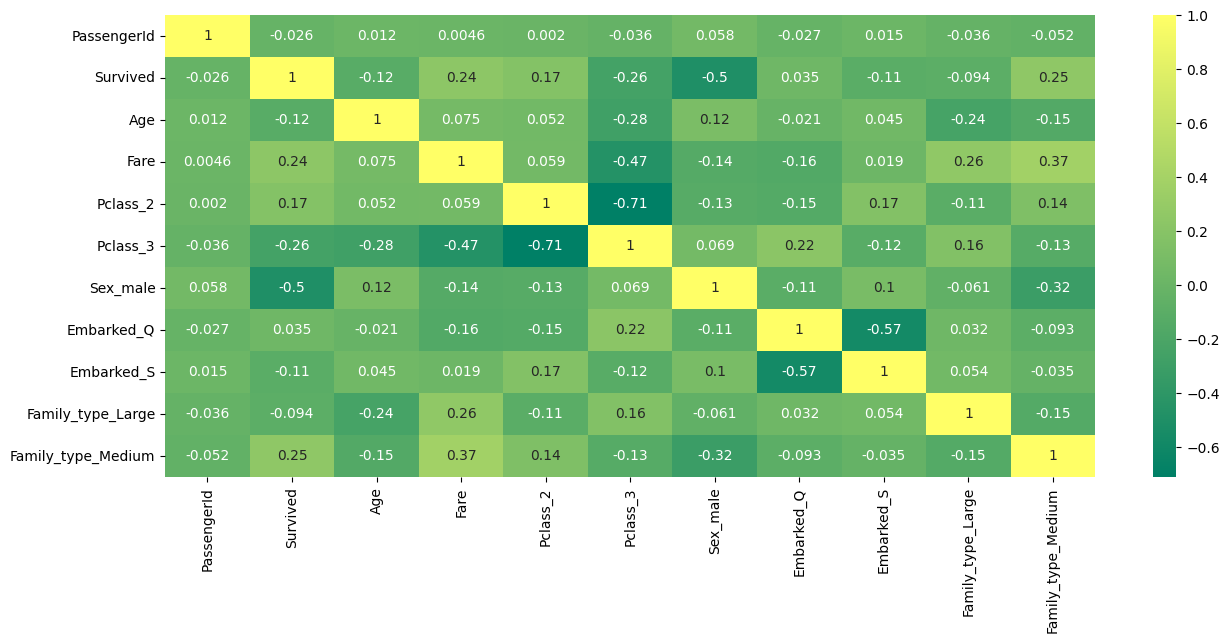

In [ ]:
plt.figure(figsize=(15,6))

colm = [
    'PassengerId', 'Survived', 'Age', 'Fare',
    'Pclass_2', 'Pclass_3',
    'Sex_male',
    'Embarked_Q', 'Embarked_S',
    'Family_type_Large', 'Family_type_Medium'
]

sns.heatmap(
    df[colm].corr(),
    annot=True,
    cmap='summer'
)

plt.show()

# DRAWING CONCLUSIONS
1. chance of survival of female is higher then male
2. travelling in Pclass 3 was deadliest
3. somehow , pwople going to C survived
4. People in the age range of 20 to 40 had a higher chance of not surviving
5. people travelling with smaller families had a higher chance of surviving the accident in comparison to people with large families and travelling alone

# COMMUNICATING RESULTS
1. report/blog
2. ppts
3. describe the results face to face